# BirdCLEF 2026: Perch Baseline EDA

This notebook explores the performance of the Google Perch (v1) model on the BirdCLEF 2026 training data. We will analyze the model's predictions, confidence scores, and embeddings.

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
import IPython.display as ipd

# Settings
DATA_DIR = "../data/raw"
TRAIN_AUDIO_DIR = os.path.join(DATA_DIR, "train_audio")
SAMPLE_RATE = 32000
WINDOW_SIZE = 5 # seconds

2026-03-11 20:13:30.504034: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/juan.lopez.arriaza/dev/birdclef_2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Metadata

Let's look at the distribution of species in the training set.

Total training samples: 35549
Unique species: 206


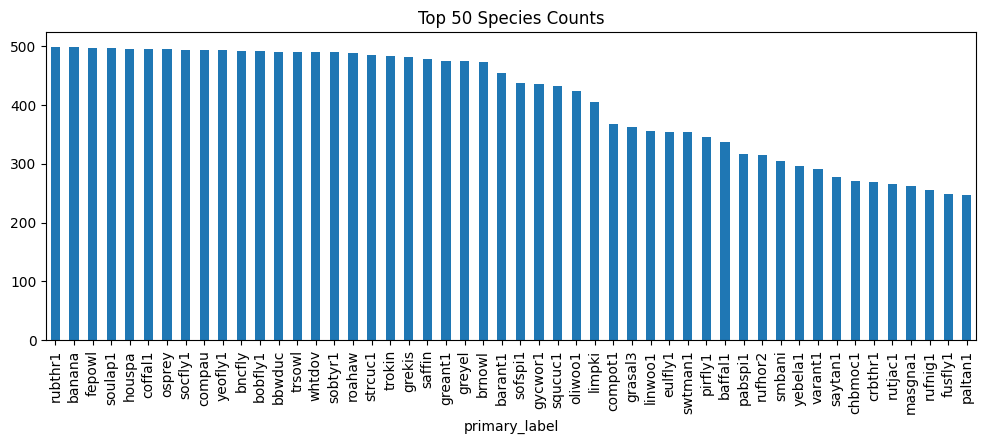

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(f"Total training samples: {len(train_df)}")
print(f"Unique species: {train_df['primary_label'].nunique()}")

species_counts = train_df['primary_label'].value_counts()
plt.figure(figsize=(12, 4))
species_counts.head(50).plot(kind='bar')
plt.title("Top 50 Species Counts")
plt.show()

## 2. Load Perch Model

We use the v1 SavedModel which is stable on CPU.

In [3]:
def load_perch_model():
    model_path = kagglehub.model_download('google/bird-vocalization-classifier/tensorFlow2/bird-vocalization-classifier')
    model = tf.saved_model.load(model_path)
    labels_path = os.path.join(model_path, "assets/label.csv")
    perch_labels = pd.read_csv(labels_path)
    return model, perch_labels

perch_model, perch_labels = load_perch_model()
print(f"Perch model loaded with {len(perch_labels)} classes.")

Perch model loaded with 10932 classes.


## 3. Inference Utilities

In [4]:
def get_predictions(audio, model):
    # Take first 5 seconds
    num_samples = WINDOW_SIZE * SAMPLE_RATE
    if len(audio) < num_samples:
        audio = np.pad(audio, (0, num_samples - len(audio)))
    segment = audio[:num_samples].astype(np.float32)
    inputs = tf.constant(segment[np.newaxis, :])
    
    infer = model.signatures['serving_default']
    input_key = list(infer.structured_input_signature[1].keys())[0]
    outputs = infer(**{input_key: inputs})
    return outputs

def plot_sample(audio, title):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(audio, sr=SAMPLE_RATE)
    plt.title(f"Waveform: {title}")
    
    plt.subplot(1, 2, 2)
    S = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Mel-spectrogram")
    plt.tight_layout()
    plt.show()

## 4. Single Sample Deep Dive

Let's pick a random sample and see what Perch thinks.

/Users/juan.lopez.arriaza/dev/birdclef_2026/.venv/lib/python3.11/site-packages/numba/cpython/hashing.py:482: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)


Target Species: Social Flycatcher (socfly1)


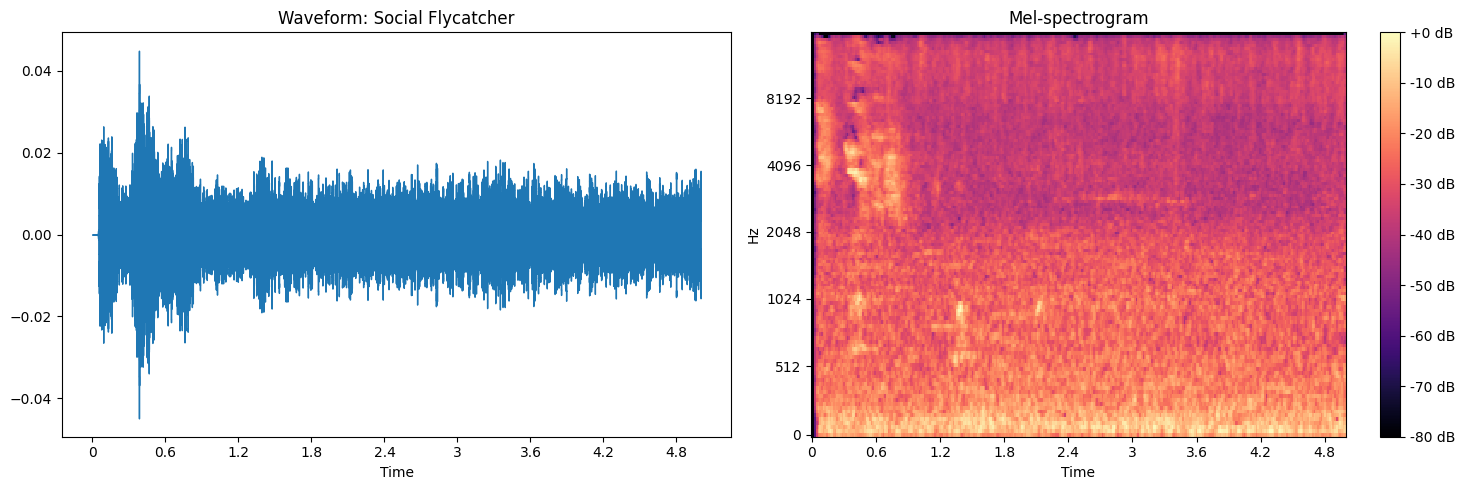

2026-03-11 20:15:45.393450: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fe3ea55b0d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-11 20:15:45.393470: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-03-11 20:15:45.394659: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 20:15:45.948827: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 20:15:46.681837: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:38] Ignoring Assert operator jax2tf_infer_fn_/assert_equal_1/Assert/AssertGuard/Assert
I0000 00:00:177328


Top 5 Perch Predictions:
- railor7: -1.2676
- senpar: -1.8529
- socfly1: -1.9856
- yehcar1: -2.7938
- juffir1: -4.0425


In [5]:
sample = train_df.sample(1).iloc[0]
audio_path = os.path.join(TRAIN_AUDIO_DIR, sample['filename'])
audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=WINDOW_SIZE)

print(f"Target Species: {sample['common_name']} ({sample['primary_label']})")
plot_sample(audio, sample['common_name'])
ipd.display(ipd.Audio(audio, rate=SAMPLE_RATE))

outputs = get_predictions(audio, perch_model)
probs = outputs['label'].numpy()[0]
top_indices = np.argsort(probs)[::-1][:5]

print("\nTop 5 Perch Predictions:")
for idx in top_indices:
    label_row = perch_labels.iloc[idx]
    print(f"- {label_row['ebird2021']}: {probs[idx]:.4f}")

## 5. Batch Analysis (Small Subset)

Let's run inference on 50 random samples and analyze the embeddings and confidence for the true label.

In [6]:
subset = train_df.sample(50, random_state=42)
embeddings = []
confidences = []
labels = []

for _, row in tqdm(subset.iterrows(), total=len(subset)):
    try:
        path = os.path.join(TRAIN_AUDIO_DIR, row['filename'])
        audio, _ = librosa.load(path, sr=SAMPLE_RATE, duration=WINDOW_SIZE)
        out = get_predictions(audio, perch_model)
        
        embeddings.append(out['embedding'].numpy()[0])
        
        # Check if the primary label exists in Perch labels
        # Note: Mapping might need tuning if labels differ
        labels.append(row['primary_label'])
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:11<00:00,  1.44s/it]

Embeddings shape: (50, 1280)


In [9]:
embeddings

array([[ 0.0061251 ,  0.05199977, -0.01116856, ...,  0.04307628,
         0.04283698, -0.00665877],
       [-0.0242815 , -0.11834266,  0.00437618, ...,  0.130919  ,
         0.22097711,  0.00104512],
       [ 0.01213721, -0.03847853,  0.03589826, ...,  0.04020206,
         0.0512366 ,  0.01241893],
       ...,
       [-0.00931653, -0.09926341,  0.08165649, ...,  0.16128448,
         0.12702851, -0.01223736],
       [-0.06541773,  0.09989194,  0.08944012, ...,  0.08549024,
         0.06500819, -0.00423243],
       [-0.0133499 ,  0.14709993, -0.01025875, ...,  0.00945715,
         0.06128142, -0.01896245]], dtype=float32)

## 6. Embedding Projection (PCA)

Visualizing the high-dimensional embeddings in 2D.

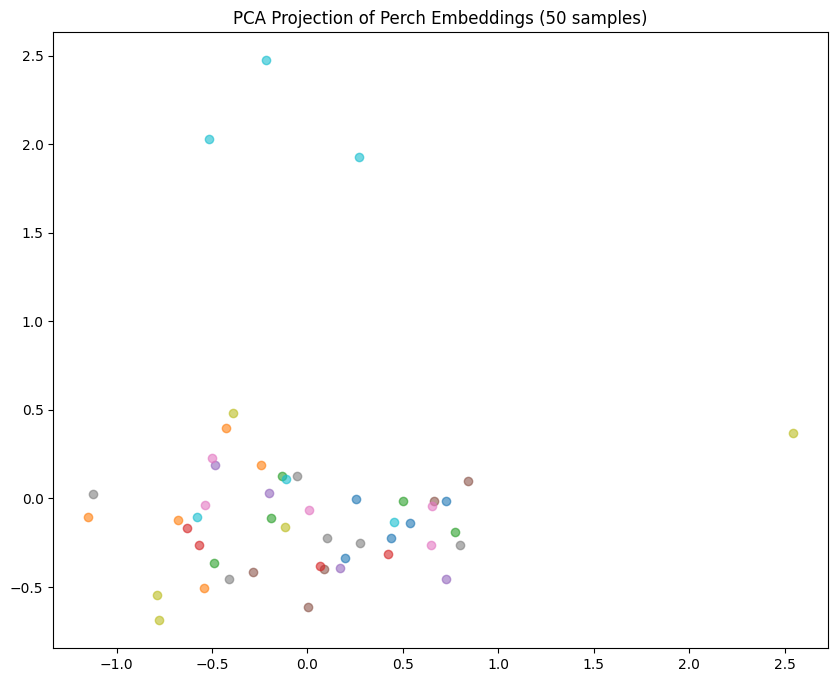

In [7]:
pca = PCA(n_components=2)
pca_res = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
unique_labels = list(set(labels))
for label in unique_labels:
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(pca_res[idx, 0], pca_res[idx, 1], label=label, alpha=0.6)

plt.title("PCA Projection of Perch Embeddings (50 samples)")
if len(unique_labels) < 15: # Only show legend if not too many
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()